# A Máquina do Tempo Financeira da Indústria Cinematográfica

**Objetivo:** Compreender a evolução do modelo de negócio do cinema ao longo das décadas, analisando como o risco financeiro (Orçamentos) e o sucesso comercial (Receitas) escalaram na era moderna.

### Perguntas de Negócio
1. **A Inflação do Entretenimento:** Como evoluíram os Orçamentos Médios e as Receitas Médias do cinema ao longo das décadas?
   
2. **A Era do Blockbuster:** A partir de que momento histórico é que a indústria do cinema começou a operar com receitas na casa dos milhares de milhões de dólares?
   
3. **Margem de Lucro (ROI - Return On Investment):** O aumento gigantesco dos orçamentos nas últimas décadas traduziu-se num aumento proporcional da rentabilidade (ROI), ou a indústria está assumir mais riscos por margens menores?

In [4]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas_datareader.data as web # Biblioteca para consumir APIs financeiras

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf
import src.view.plots._formatters as fmtt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Caminho central para a base de dados relacional


In [5]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## A Inflação do Entretenimento 

In [6]:
query_decadas = """
    SELECT 
        id,
        decade,
        ROUND(AVG(budget), 2) AS 'orcamento_medio',
        ROUND(AVG(revenue), 2) AS 'faturamento_medio'
    FROM unified_media_catalog 
    WHERE media_type = 'Movie' 
    GROUP BY decade
    ORDER BY 
        orcamento_medio DESC, 
        faturamento_medio DESC;
"""

df_decadas = dbc.execute_query(
    caminho_banco,
    alvo=query_decadas, 
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df=df_decadas.set_index('decade'),
        caption='Relatório Financeiro Através das Décadas'
    )
    .bar(subset=['orcamento_medio'],color='#D4A373')
    .bar(subset=['faturamento_medio'],color='#588157')
    .format({
        'orcamento_medio': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}',
        'faturamento_medio': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
    })
)


Dados carregados via SQL! Formato: (15, 4)


,id,orcamento_medio,faturamento_medio
decade,,,
2000,19457,"US$ 27,203,255.66","US$ 79,558,100.44"
1990,862,"US$ 26,190,648.41","US$ 64,111,293.13"
2010,79782,"US$ 25,564,266.61","US$ 90,898,374.35"
1980,78,"US$ 11,368,329.57","US$ 36,517,681.32"
1960,649,"US$ 4,827,756.69","US$ 26,623,865.74"
1970,103,"US$ 4,363,765.01","US$ 47,500,679.07"
1920,85638,"US$ 3,390,127.22","US$ 3,046,327.31"
1950,5801,"US$ 2,395,612.06","US$ 23,579,749.70"
1940,10895,"US$ 1,636,960.62","US$ 15,411,126.25"


#### Ajustar Valores com a Inflação Média da Década

In [7]:
# Ajuste De Inflação (Via api FRED - Federal Reserve)

df_inflacao = df_decadas.copy()

df_cpi = web.DataReader(
    'CPIAUCNS', 
    'fred', 
    datetime.datetime(1910, 1, 1), 
    datetime.datetime(2023, 12, 31)
)

# Transformações
df_cpi = df_cpi.reset_index()
df_cpi['year'] = df_cpi['DATE'].dt.year
df_cpi['decade'] = (df_cpi['year'] // 10) * 10

# Média do índice por década
cpi_decadas = df_cpi.groupby('decade')['CPIAUCNS'].mean().reset_index()

# Âncora de 2023
cpi_atual = df_cpi[df_cpi['year'] == 2023]['CPIAUCNS'].mean()

# Multiplicador
cpi_decadas['fator_inflacao'] = cpi_atual / cpi_decadas['CPIAUCNS']
cpi_decadas['decade'] = cpi_decadas['decade'].astype(int)
df_decadas['decade'] = df_decadas['decade'].astype(int)

# Apaga colunas velhas 
colunas_lixo = [col for col in df_decadas.columns if 'fator_inflacao' in col or 'Ajustado' in col]
df_decadas = df_decadas.drop(columns=colunas_lixo, errors='ignore')

# O Merge final, limpo e com todas as décadas!
df_decadas = df_decadas.merge(cpi_decadas[['decade', 'fator_inflacao']], on='decade', how='left')

# Cálculos Ajustados
df_decadas['orcamento_ajustado'] = df_decadas['orcamento_medio'] * df_decadas['fator_inflacao']
df_decadas['faturamento_ajustado'] = df_decadas['faturamento_medio'] * df_decadas['fator_inflacao']

# Ordenar cronologicamente
df_inflacao = df_decadas.sort_values('decade')

In [8]:
display(
    tb.estilizar_tabela(
        df=df_inflacao.set_index('decade'),
        colunas_selecionadas=[
            'orcamento_medio',
            'orcamento_ajustado',
            'faturamento_medio',
            'faturamento_ajustado',
            'fator_inflacao'
        ],
        caption='Valores Financeiros Ajustados pela Inflação (Base 2023)'
    )
    .background_gradient(subset=['orcamento_medio'], cmap='YlOrBr')
    .background_gradient(subset=['orcamento_ajustado'], cmap='Oranges')
    .background_gradient(subset=['faturamento_medio'], cmap='Greens')
    .background_gradient(subset=['faturamento_ajustado'], cmap='YlGn')
    .background_gradient(subset=['fator_inflacao'], cmap='Purples')
    .format({**
        {
            col: lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
            for col in df_inflacao.columns[:-1]
        },
        'fator_inflacao': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}x'
    })
)

,orcamento_medio,orcamento_ajustado,faturamento_medio,faturamento_ajustado,fator_inflacao
decade,,,,,
1870,NaN,NaN,NaN,nan,NaN
1880,NaN,NaN,NaN,nan,NaN
1890,NaN,NaN,NaN,nan,NaN
1900,"US$ 6,742.50",NaN,NaN,nan,NaN
1910,"US$ 1,284,356.00","US$ 31,819,771.34","US$ 6,784,341.25",168081269.715310,24.77x
1920,"US$ 3,390,127.22","US$ 58,780,944.52","US$ 3,046,327.31",52819845.677650,17.34x
1930,"US$ 974,881.00","US$ 20,942,209.10","US$ 19,558,079.37",420142958.768439,21.48x
1940,"US$ 1,636,960.62","US$ 26,580,575.15","US$ 15,411,126.25",250242183.284034,16.24x
1950,"US$ 2,395,612.06","US$ 27,010,056.90","US$ 23,579,749.70",265857060.802727,11.27x


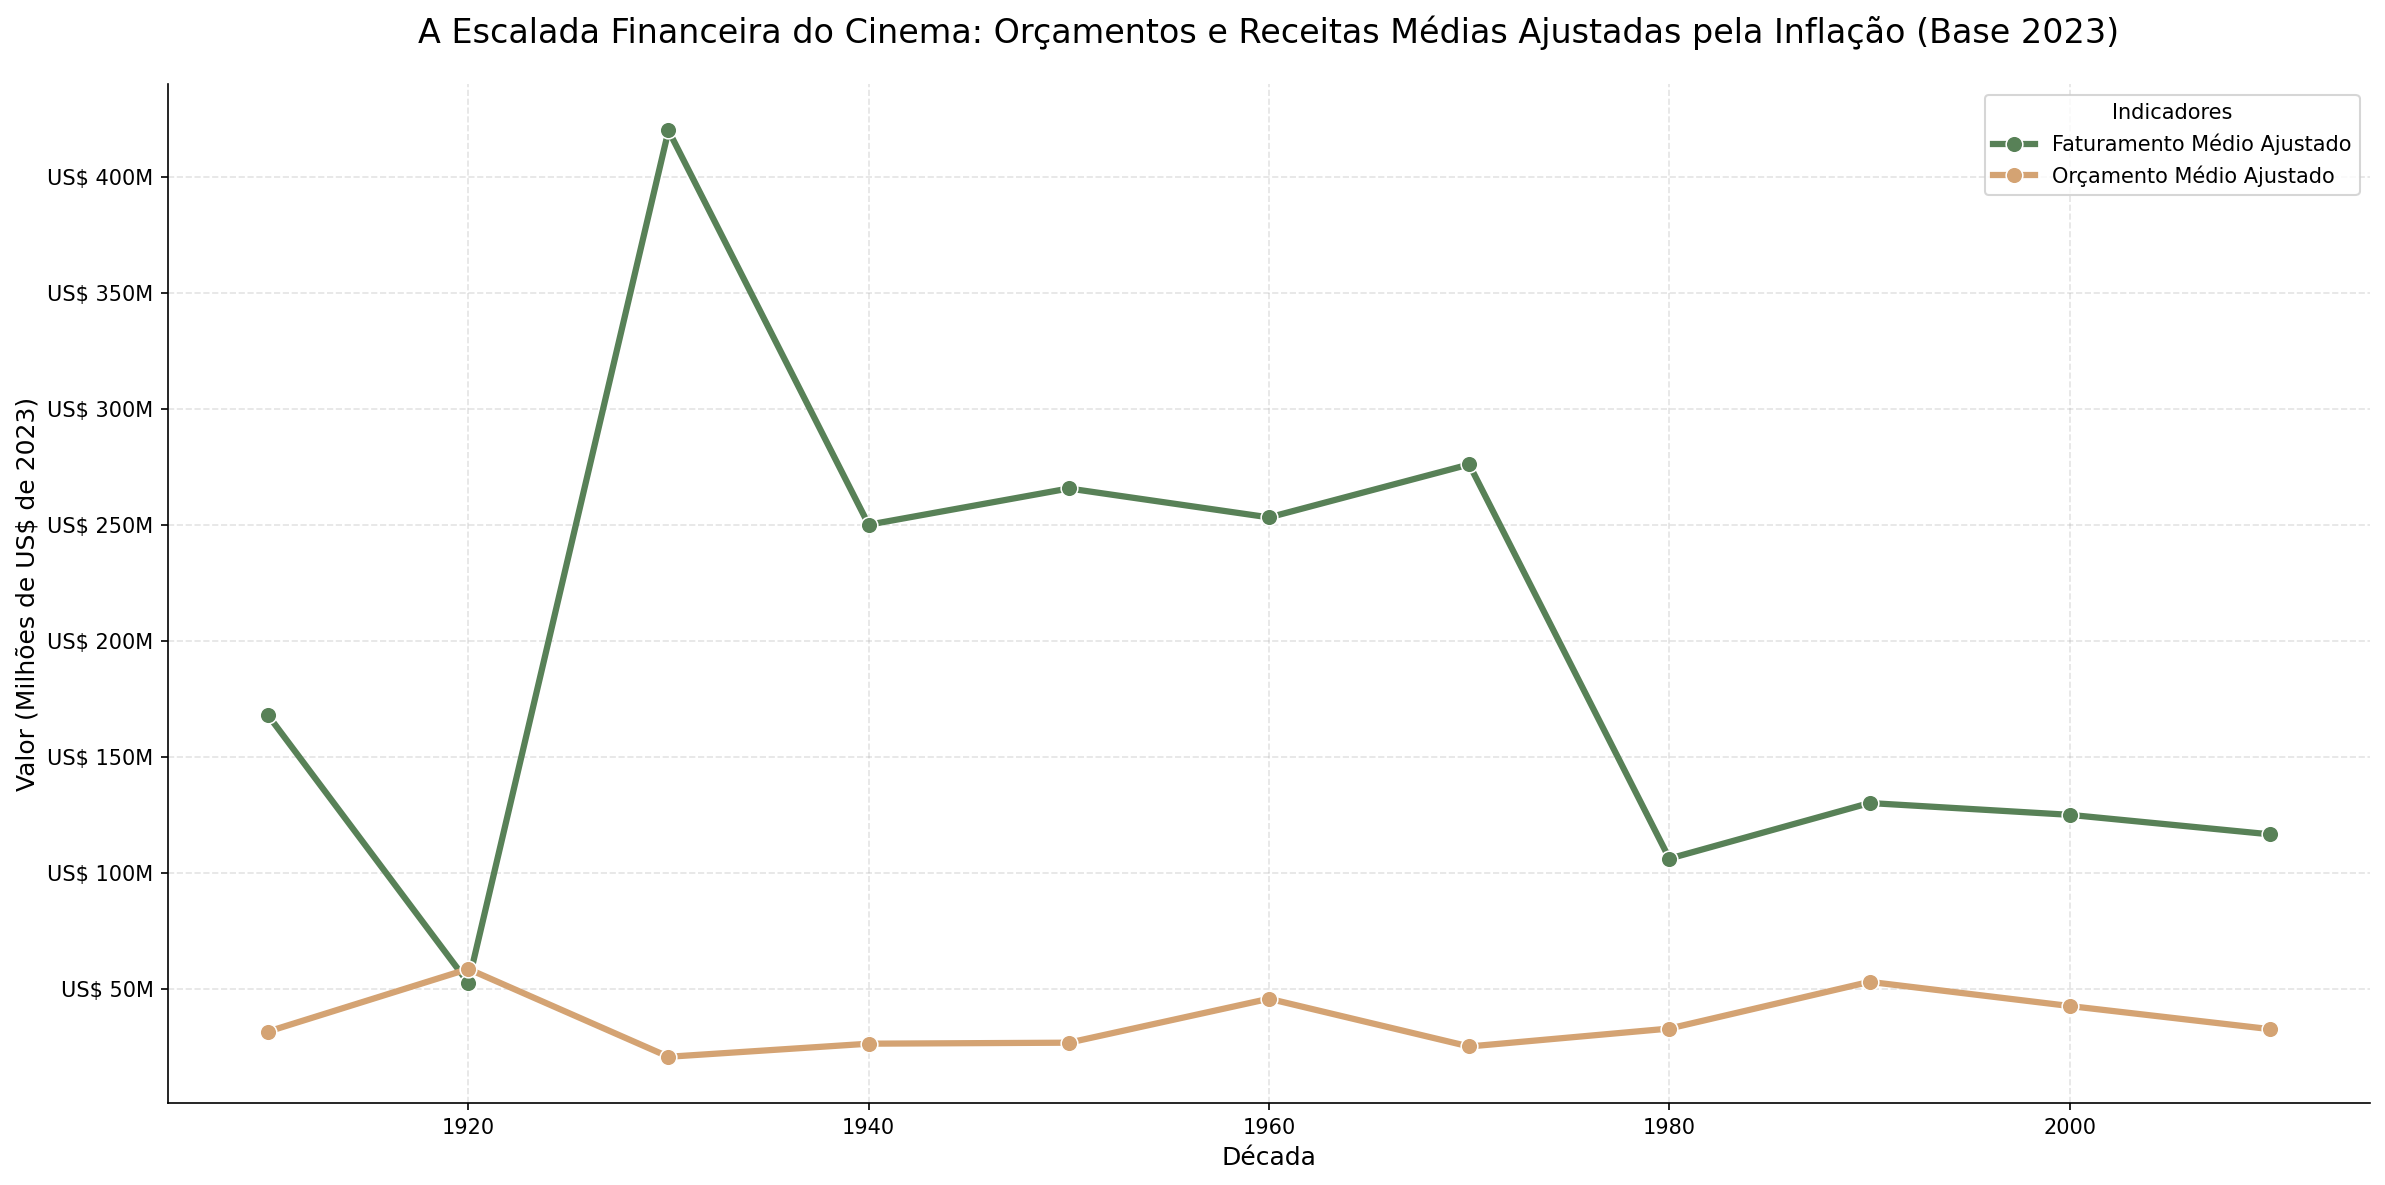

In [9]:
df_inflacao_limpo = df_inflacao.dropna(
    subset=['orcamento_ajustado', 'faturamento_ajustado']
)

# Gráfico: A evolução financeira do cinema ajustada pela inflação

plt.figure(figsize=(16, 8), dpi=150)

ax = sns.lineplot(
    data=df_inflacao_limpo,
    x='decade',
    y='faturamento_ajustado',
    marker='o',
    markersize=8,
    color='#588157',
    linewidth=3,
    label='Faturamento Médio Ajustado'
)

sns.lineplot(
    data=df_inflacao_limpo,
    x='decade',
    y='orcamento_ajustado',
    marker='o',
    markersize=8,
    color='#D4A373',
    linewidth=3,
    label='Orçamento Médio Ajustado',
    ax=ax
)


# Título e rótulos
ax.set_title(
    'A Escalada Financeira do Cinema: Orçamentos e Receitas Médias Ajustadas pela Inflação (Base 2023)',
    fontsize=16,
    pad=20
)

ax.set_xlabel('Década', fontsize=12)
ax.set_ylabel('Valor (Milhões de US$ de 2023)', fontsize=12)

# Formatação do eixo Y em milhões
formatter = ticker.FuncFormatter(
    lambda x, pos: f'US$ {x * 1e-6:.0f}M'
)
ax.yaxis.set_major_formatter(formatter)

# Melhorias visuais
ax.grid(
    True,
    linestyle='--',
    alpha=0.35
)

ax.legend(
    title='Indicadores',
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

---
## A Era do Blockbuster

In [10]:
query_bloc = """
    SELECT
        decade,
        COUNT(*) AS quantidade_blockbusters,
        MAX(revenue) AS maior_faturamento
    FROM (
        SELECT 
            decade,
            revenue,
            PERCENT_RANK() OVER (
                PARTITION BY decade
                ORDER BY revenue DESC
            ) AS ranking
        FROM unified_media_catalog
        WHERE media_type = 'Movie'
    )
    WHERE ranking <= 0.05
    GROUP BY decade
    ORDER BY quantidade_blockbusters DESC;
"""

df_bloc = dbc.execute_query(
    caminho_banco,
    alvo=query_bloc,
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df=df_bloc.set_index('decade'),
        caption='Blockbuster por Década'
    )
    .bar(
        subset=['quantidade_blockbusters'],
        color='#457B9D'
    )
    .background_gradient(
        subset=['maior_faturamento'],
        cmap='Greens'
    )
    .format({
        'quantidade_blockbusters': '{:,.0f}',
        'maior_faturamento': lambda x: 'NaN' if pd.isna(x) else f'US$ {x:,.2f}'
    })
)


Dados carregados via SQL! Formato: (15, 3)


,quantidade_blockbusters,maior_faturamento
decade,,
1950,"1,902","US$ 572,000,000.00"
1940,"1,362","US$ 267,447,150.00"
1930,"1,143","US$ 400,176,459.00"
2010,582,"US$ 2,068,223,624.00"
2000,508,"US$ 2,787,965,087.00"
1920,380,"US$ 22,000,000.00"
1990,257,"US$ 1,845,034,188.00"
1980,182,"US$ 792,965,326.00"
1910,159,"US$ 11,000,000.00"


#### Ajustar Valores com a Inflação Média da Década

In [11]:
# Ajuste de Inflação para Blockbusters (Base 2023)

df_bloc = df_bloc.copy()

# Garantir o tipo da década
df_bloc['decade'] = df_bloc['decade'].astype(int)

# CPI 
df_cpi['year'] = df_cpi['DATE'].dt.year
df_cpi['decade'] = (df_cpi['year'] // 10) * 10

# Média do CPI por década
cpi_decadas = (
    df_cpi
    .groupby('decade')['CPIAUCNS']
    .mean()
    .reset_index()
)

# Âncora de 2023
cpi_atual = df_cpi[df_cpi['year'] == 2023]['CPIAUCNS'].mean()

# Multiplicador de inflação
cpi_decadas['fator_inflacao'] = (
    cpi_atual / cpi_decadas['CPIAUCNS']
)

# Garantir o tipo
cpi_decadas['decade'] = cpi_decadas['decade'].astype(int)

# Remover colunas antigas
colunas_lixo = [
    col for col in df_bloc.columns 
    if 'fator_inflacao' in col 
    or 'ajustado' in col.lower()
]

df_bloc = df_bloc.drop(columns=colunas_lixo, errors='ignore')

# Merge 
df_bloc = df_bloc.merge(
    cpi_decadas[['decade', 'fator_inflacao']],
    on='decade',
    how='left'
)

# Ajuste do maior faturamento para dólar de 2023
df_bloc['maior_faturamento_ajustado'] = (
    df_bloc['maior_faturamento'] * df_bloc['fator_inflacao']
)


In [12]:
display(
    tb.estilizar_tabela(
        df=df_bloc.set_index('decade'),
        colunas_selecionadas=[
            'quantidade_blockbusters',
            'maior_faturamento',
            'maior_faturamento_ajustado',
            'fator_inflacao'
        ],
        caption='Blockbusters por Década: Ajustado pela Inflação (Base 2023)'
    ) 
    .bar(subset=['quantidade_blockbusters'],color='#1D3557')
    .background_gradient(subset=['maior_faturamento'],cmap='YlGn')
    .background_gradient(subset=['maior_faturamento_ajustado'], cmap='YlOrRd')
    .background_gradient(subset=['fator_inflacao'], cmap='Purples')
    .format({
        'quantidade_blockbusters': '{:,.0f}',
        'maior_faturamento': lambda x: ('NaN' if pd.isna(x)else f'US$ {x:,.0f}'),
        'maior_faturamento_ajustado': lambda x: ('NaN' if pd.isna(x) else f'US$ {x:,.0f}'),
        'fator_inflacao': lambda x: 'NaN' if pd.isna(x) else f'{x:.2f}x'
    })
)


,quantidade_blockbusters,maior_faturamento,maior_faturamento_ajustado,fator_inflacao
decade,,,,
1950,"1,902","US$ 572,000,000","US$ 6,449,187,999",11.27x
1940,"1,362","US$ 267,447,150","US$ 4,342,742,876",16.24x
1930,"1,143","US$ 400,176,459","US$ 8,596,514,941",21.48x
2010,582,"US$ 2,068,223,624","US$ 2,657,699,540",1.29x
2000,508,"US$ 2,787,965,087","US$ 4,387,789,561",1.57x
1920,380,"US$ 22,000,000","US$ 381,454,941",17.34x
1990,257,"US$ 1,845,034,188","US$ 3,749,940,557",2.03x
1980,182,"US$ 792,965,326","US$ 2,309,167,245",2.91x
1910,159,"US$ 11,000,000","US$ 272,523,728",24.77x


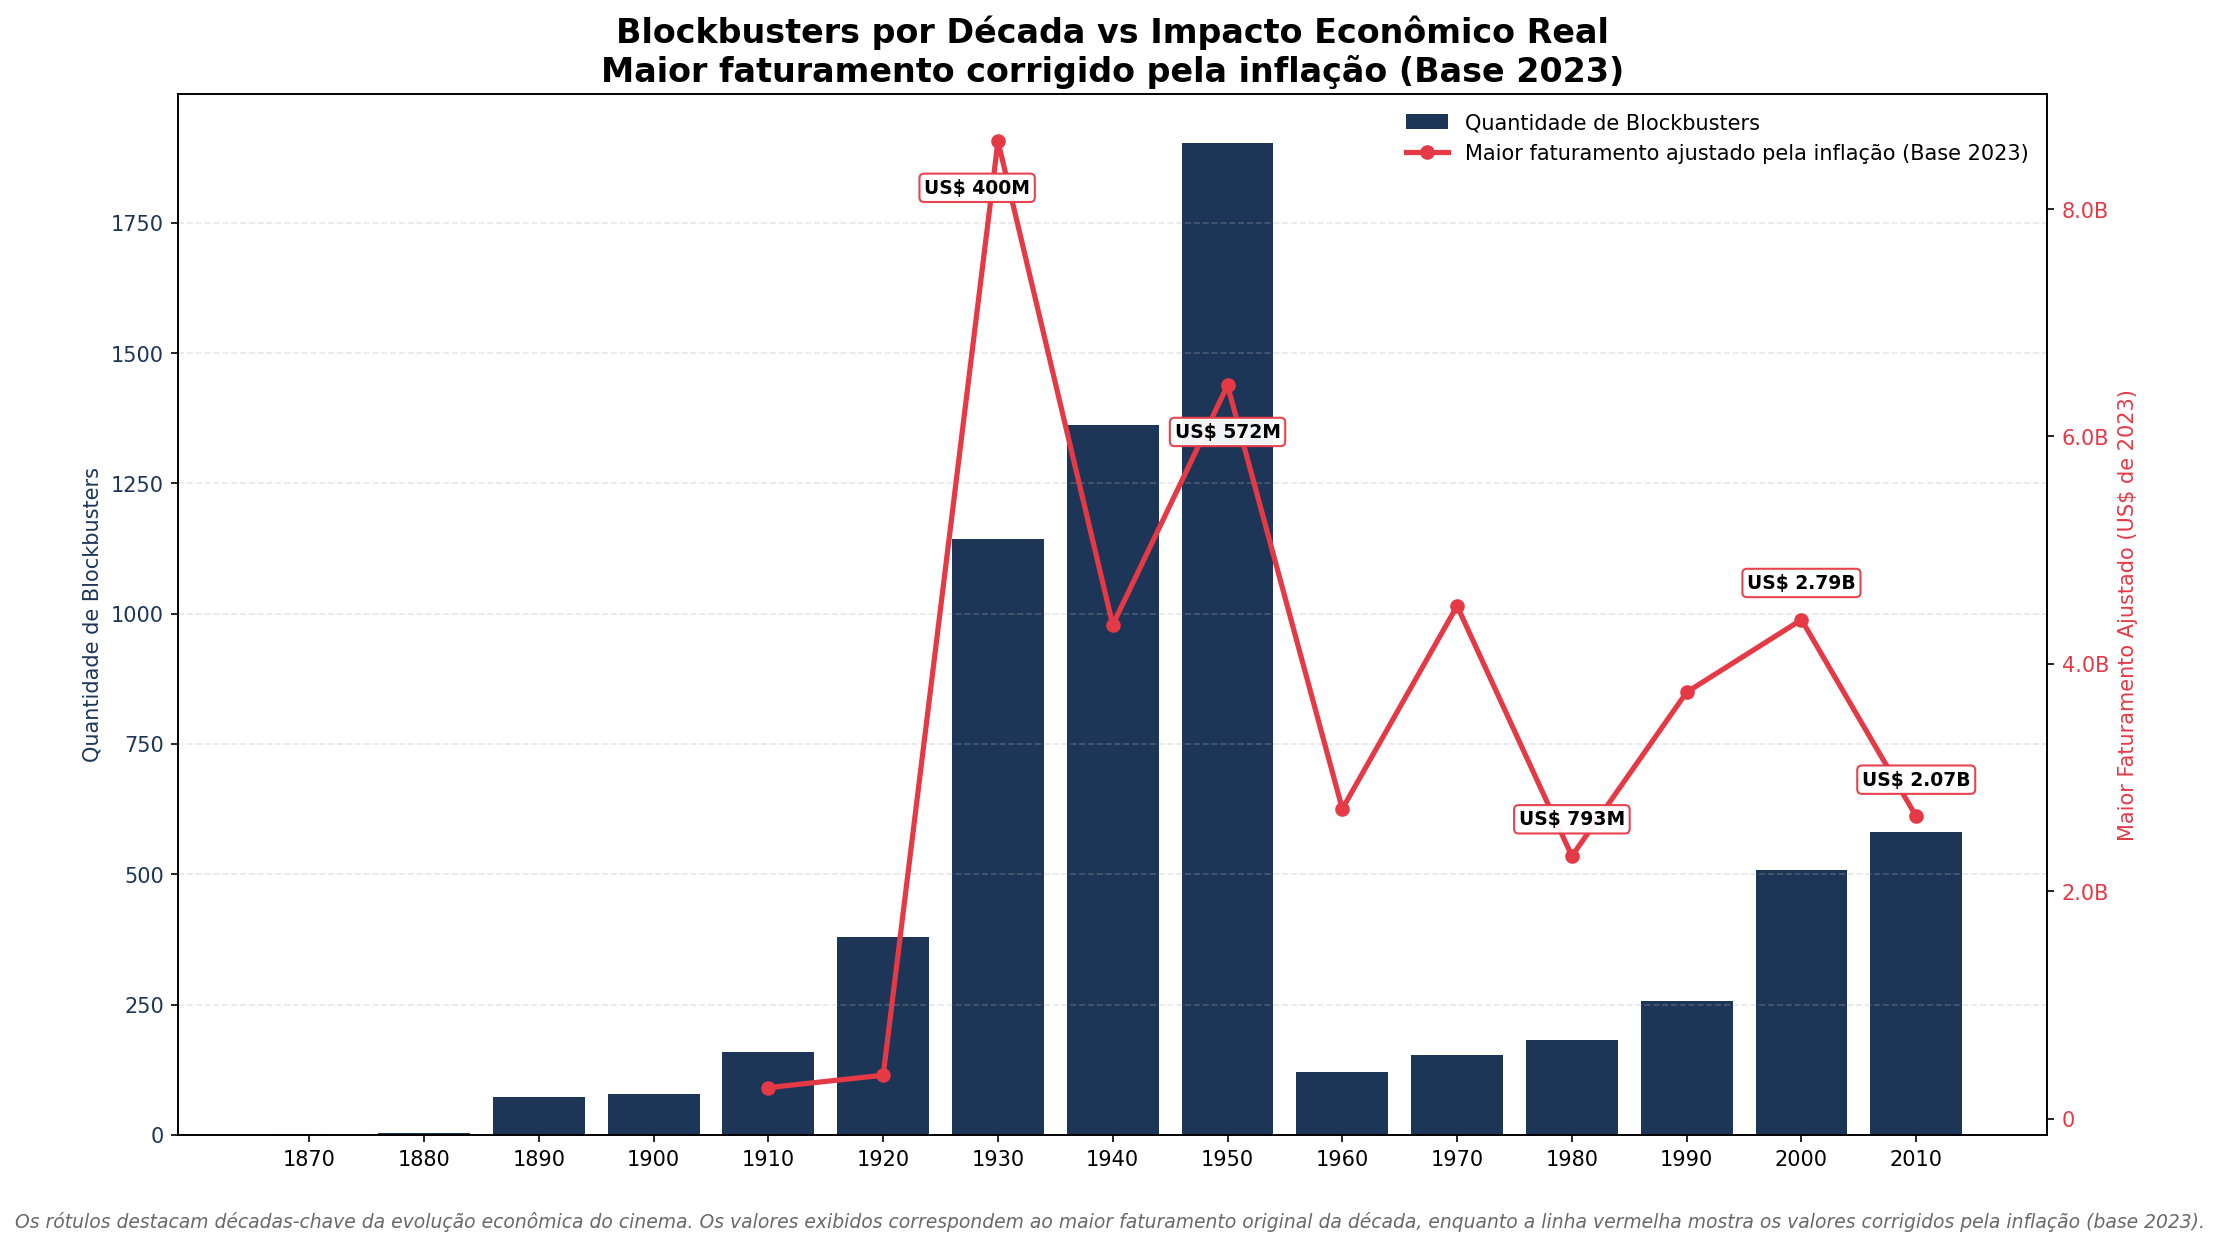

In [13]:
df_plot = df_bloc.copy()

df_plot = (
    df_plot
    .sort_values('decade')
    .reset_index(drop=True)
)

df_plot['decade'] = df_plot['decade'].astype(str)
decadas_chave = ['1930', '1950', '1980', '2000', '2010']

fig, ax1 = plt.subplots(figsize=(14, 8), dpi=150)

ax1.bar(
    df_plot['decade'],
    df_plot['quantidade_blockbusters'],
    color='#1D3557',
    label='Quantidade de Blockbusters'
)
ax1.set_ylabel('Quantidade de Blockbusters',color='#1D3557')
ax1.tick_params(axis='y',labelcolor='#1D3557')

ax2 = ax1.twinx()

ax2.plot(
    df_plot['decade'],
    df_plot['maior_faturamento_ajustado'],
    color='#E63946',
    marker='o',
    linewidth=2.5,
    label='Maior faturamento ajustado pela inflação (Base 2023)'
)

offsets = {
    '1930': (-10, -25),  # abaixo do ponto
    '1950': (0, -25),    # abaixo do ponto
    '1980': (0, 15),     # acima
    '2000': (0, 15),     # acima
    '2010': (0, 15)      # acima
}

for _, row in df_plot.iterrows():

    if row['decade'] not in decadas_chave:
        continue

    if row["maior_faturamento"] >= 1e9:
        texto = f'US$ {row["maior_faturamento"]/1e9:.2f}B'
    else:
        texto = f'US$ {row["maior_faturamento"]/1e6:.0f}M'

    dx, dy = offsets[row['decade']]

    ax2.annotate(
        texto,
        xy=(row['decade'], row['maior_faturamento_ajustado']),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='#E63946',
            alpha=0.95
        )
    )

ax2.set_ylabel('Maior Faturamento Ajustado (US$ de 2023)', color='#E63946')

ax2.tick_params(axis='y', labelcolor='#E63946')

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(fmtt._formatar_numero))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right',
    frameon=False
)

plt.title(
    'Blockbusters por Década vs Impacto Econômico Real\n'
    'Maior faturamento corrigido pela inflação (Base 2023)',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.figtext(
    0.5,
    -0.03,
    'Os rótulos destacam décadas-chave da evolução econômica do cinema. '
    'Os valores exibidos correspondem ao maior faturamento original da década, '
    'enquanto a linha vermelha mostra os valores corrigidos pela inflação (base 2023).',
    ha='center',
    fontsize=9,
    color='dimgray',
    style='italic'
)

plt.tight_layout()
plt.show()

---
## Margem de Lucro (ROI - Return On Investment)

In [14]:
query_roi = """
    SELECT
        id,
        decade,
        ((revenue - budget) / budget) * 100 AS roi
    FROM unified_media_catalog
    WHERE media_type = 'Movie'
        AND budget > 0
        AND revenue IS NOT NULL;
"""

df_roi_filmes = dbc.execute_query(
    caminho_banco,
    alvo=query_roi,
    eh_query=True
)

df_roi = (
    df_roi_filmes
    .groupby('decade')
    .agg(
        quantidade_filmes=('roi', 'count'),
        roi_medio=('roi', 'mean'),
        roi_mediano=('roi', 'median')
    )
    .round(2)
    .sort_values('roi_mediano', ascending=False)
    .reset_index()
)

display(
    tb.estilizar_tabela(
        df=df_roi.set_index('decade'),
        caption='ROI dos Filmes por Década'
    )
    .bar(subset=['quantidade_filmes'],color='#1D3557')
    .background_gradient(subset=['roi_medio'],cmap='Oranges')
    .background_gradient(subset=['roi_mediano'],cmap='Greens')
    .format({
        'quantidade_filmes': '{:,.0f}',
        'roi_medio': lambda x: '-' if pd.isna(x) else f'{x:.2f}%',
        'roi_mediano': lambda x: '-' if pd.isna(x) else f'{x:.2f}%'
    })
)


Dados carregados via SQL! Formato: (5284, 3)


,quantidade_filmes,roi_medio,roi_mediano
decade,,,
1910,4,4648.38%,3500.00%
1970,185,3157.80%,572.46%
1950,74,1063.86%,357.40%
1940,45,1254.26%,283.33%
1930,34,1103.98%,280.76%
1960,129,1210.64%,280.00%
1980,517,434.05%,144.93%
1920,15,914.50%,130.77%
2010,"1,610",448.22%,110.82%


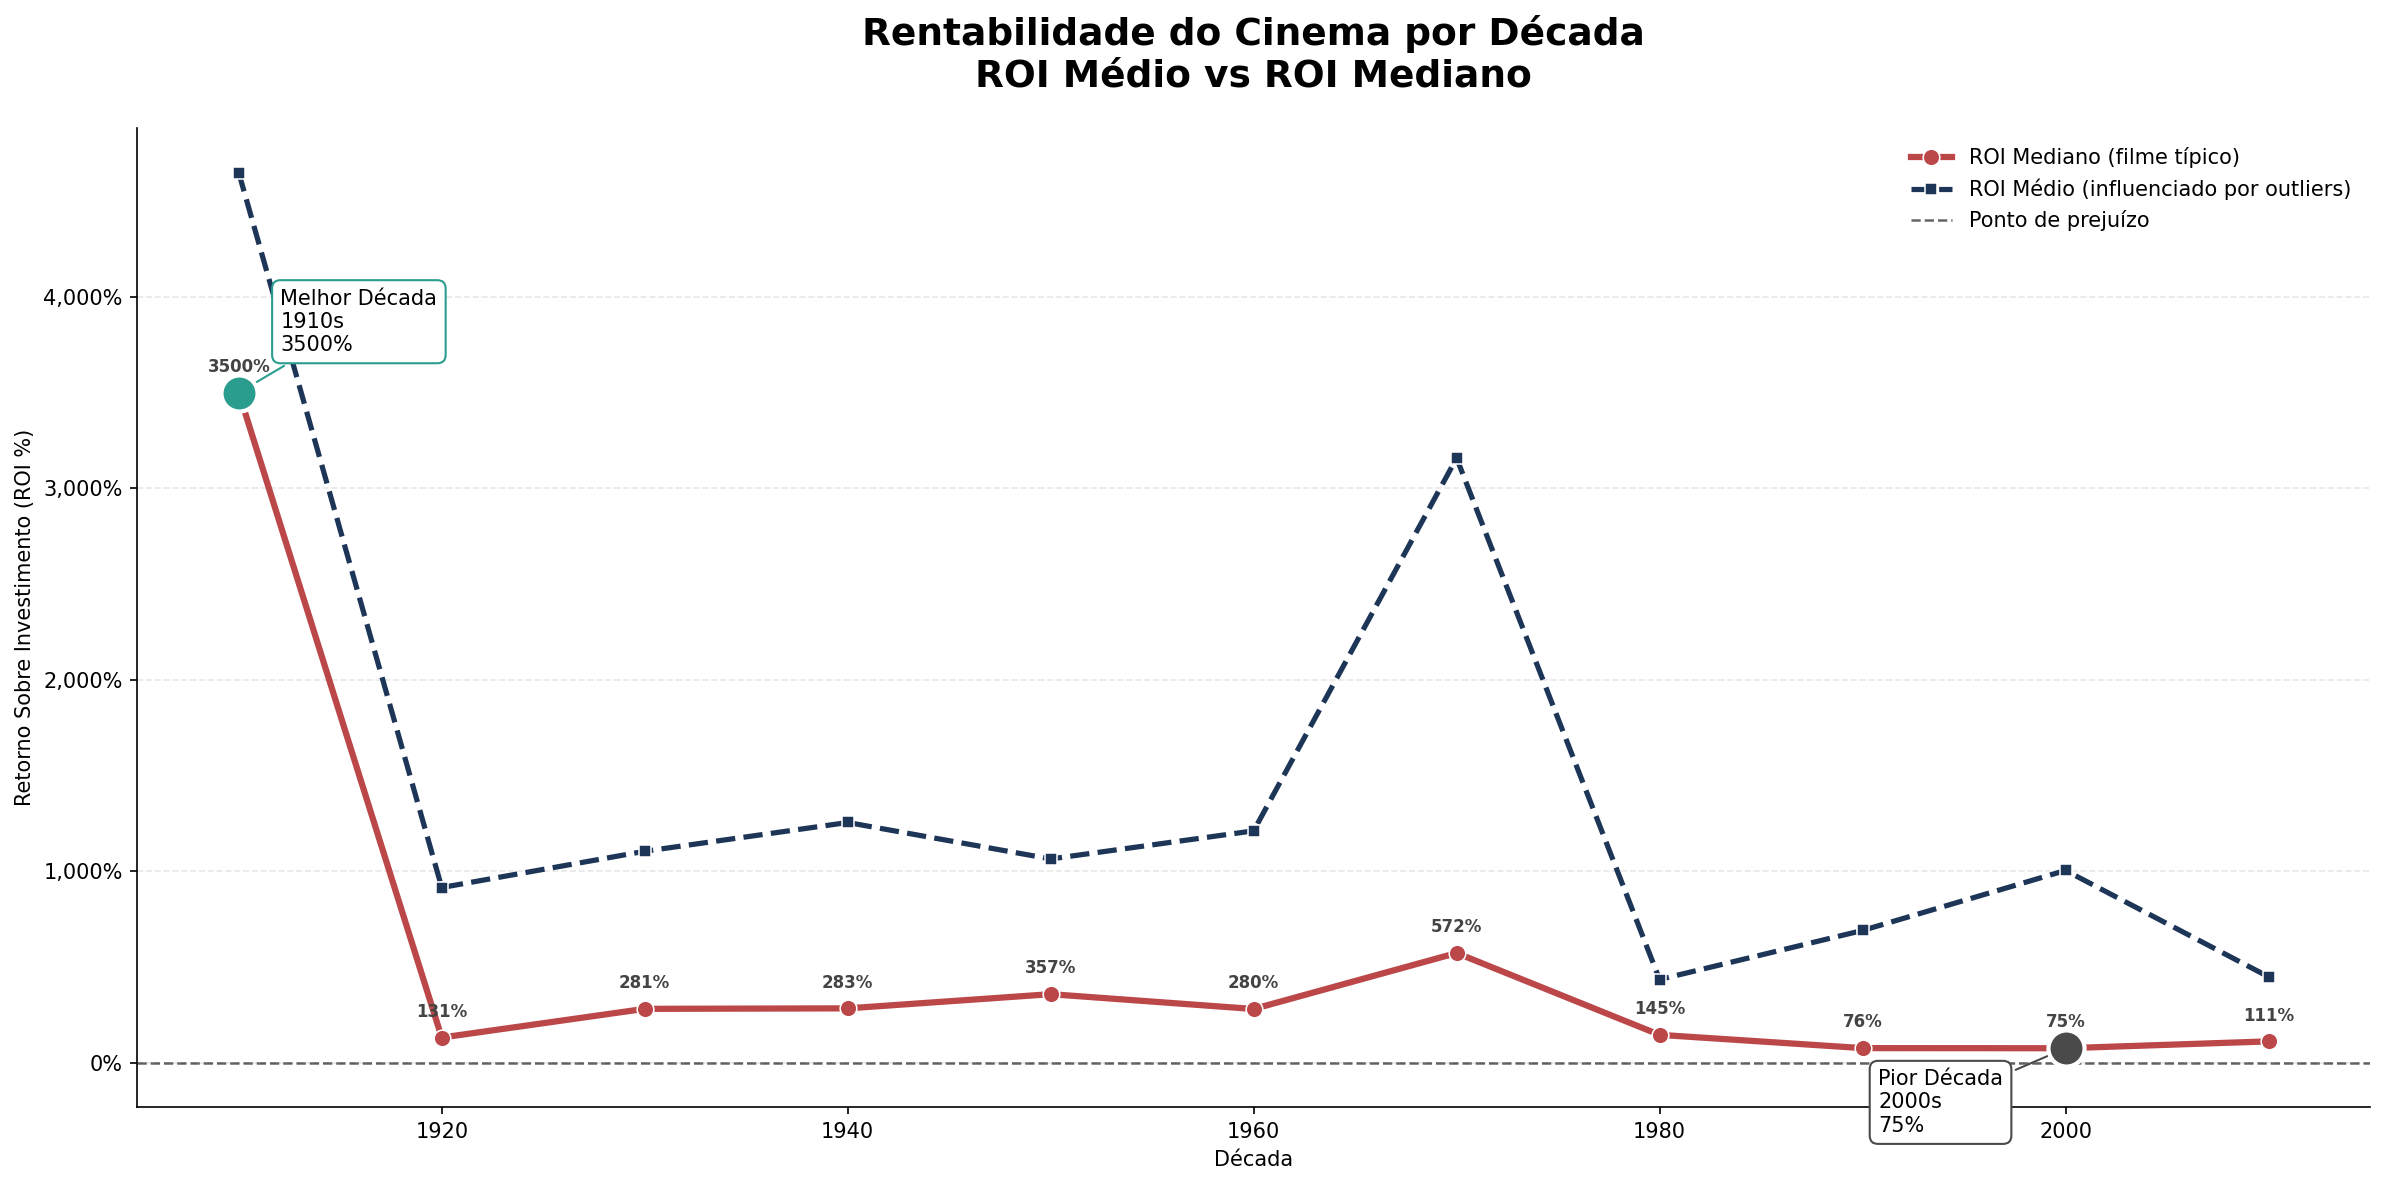

In [15]:
plt.figure(figsize=(16, 8), dpi=150)

df_plot = df_roi.sort_values('decade')

# Linha ROI Mediano
ax = sns.lineplot(
    data=df_plot,
    x='decade',
    y='roi_mediano',
    marker='o',
    markersize=8,
    linewidth=3,
    color='#BC4749',
    label='ROI Mediano (filme típico)'
)

# Linha ROI Médio
sns.lineplot(
    data=df_plot,
    x='decade',
    y='roi_medio',
    marker='s',
    markersize=6,
    linewidth=2.5,
    color='#1D3557',
    linestyle='--',
    label='ROI Médio (influenciado por outliers)',
    ax=ax
)

# Linha de equilíbrio
ax.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6,
    label='Ponto de prejuízo'
)

# Melhor e pior década pelo ROI mediano
melhor = df_plot.loc[df_plot['roi_mediano'].idxmax()]
pior = df_plot.loc[df_plot['roi_mediano'].idxmin()]

# Destaque melhor década
ax.scatter(
    melhor['decade'],
    melhor['roi_mediano'],
    s=300,
    color='#2A9D8F',
    edgecolors='white',
    linewidth=2,
    zorder=5
)

ax.annotate(
    f"Melhor Década\n{int(melhor['decade'])}s\n{melhor['roi_mediano']:.0f}%",
    xy=(melhor['decade'], melhor['roi_mediano']),
    xytext=(20, 20),
    textcoords='offset points',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#2A9D8F'
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='#2A9D8F'
    )
)

# Destaque pior década
ax.scatter(
    pior['decade'],
    pior['roi_mediano'],
    s=300,
    color='#4A4A4A',
    edgecolors='white',
    linewidth=2,
    zorder=5
)

ax.annotate(
    f"Pior Década\n{int(pior['decade'])}s\n{pior['roi_mediano']:.0f}%",
    xy=(pior['decade'], pior['roi_mediano']),
    xytext=(-90, -40),
    textcoords='offset points',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#4A4A4A'
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='#4A4A4A'
    )
)

# Valores em todos os pontos do ROI mediano
for _, row in df_plot.iterrows():
    ax.annotate(
        f"{row['roi_mediano']:.0f}%",
        xy=(row['decade'], row['roi_mediano']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold',
        color='#444'
    )

# Títulos e eixos
ax.set_title(
    'Rentabilidade do Cinema por Década\n'
    'ROI Médio vs ROI Mediano',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Década')
ax.set_ylabel('Retorno Sobre Investimento (ROI %)')

# Formatação percentual correta
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}%'))

# Grade
ax.grid(axis='y',linestyle='--',alpha=0.3)

# Legenda
ax.legend(frameon=False,loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

### Salvando Nova Tabela 

In [16]:
# Merge para preservar todas as novas colunas
df = df_inflacao.merge(
    df_bloc.drop(columns='fator_inflacao'),
    on='decade',
    how='left'
).merge(
    df_roi,
    on='decade',
    how='left'
)

df.columns

Index(['id', 'decade', 'orcamento_medio', 'faturamento_medio',
       'fator_inflacao', 'orcamento_ajustado', 'faturamento_ajustado',
       'quantidade_blockbusters', 'maior_faturamento',
       'maior_faturamento_ajustado', 'quantidade_filmes', 'roi_medio',
       'roi_mediano'],
      dtype='object')

In [17]:
dbc.save_db(
    df=df,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='cinema_financial_decade'
)

# Para uso no Power BI
df.to_excel(
    '../../data/powerbi_export/cinema_financial_decade.xlsx', 
    index=False
)


Sucesso! Tabela 'cinema_financial_decade' criada no banco: 'unified_media_catalog.db'


---
## Conclusões: A Máquina do Tempo Financeira e o Risco do Mundo do Cinema

**1. A Inflação do Entretenimento (Orçamentos vs. Receitas)**

* **A Descoberta:** Ao ajustarmos os valores pela inflação real (trazendo o dinheiro para o poder de compra de ~2023), fica provado que o custo de fazer cinema e as receitas geradas escalaram massivamente. Fazer filmes tornou-se, na prática, incomparavelmente mais caro hoje do que no início do século passado, mas a capacidade de gerar receita bruta acompanhou e superou esse aumento de custos.

* **O Racional de Negócio:** O cinema moderno exige um nível de capital intensivo que os estúdios clássicos não imaginavam. O avanço tecnológico (CGI, captação digital), os salários das estrelas e, principalmente, as campanhas de marketing globais encareceram o "preço de admissão" para competir na indústria. Para suportar este custo, filmes de grande magnitude expandiram agressivamente o seu mercado para além do público nacional, dependendo hoje profundamente da bilheteira global para viabilizar as suas produções.

**2. A Era do Blockbuster (O Ponto de Inflexão)**

* **A Descoberta:** O gráfico de evolução temporal mostra que, até aos anos 1960, a linha de receitas e orçamentos crescia de forma moderada e paralela. Contudo, a partir do final da década de 1970, e especialmente nos anos 1980 e 1990, a curva da Receita Média sofre um descolamento vertical violento, criando um "fosso" em relação aos custos.

* **O Racional de Negócio:** Este é o nascimento oficial e estatístico da "Era do Blockbuster" (inaugurada por Tubarão e cimentada por Star Wars). Hollywood descobriu que um filme podia deixar de ser "apenas um filme" para se transformar num evento cultural contínuo. Este novo paradigma de negócios trouxe fontes de receita estratosféricas que não existiam: o mercado de Home Video (VHS/DVD), contratos de televisão, merchandising de brinquedos e franchising (sequelas infinitas).

**3. Margem de Lucro e ROI (O Aumento do Risco)**

* **A Descoberta:** O aumento gigantesco dos orçamentos não se traduziu num aumento proporcional da rentabilidade. Pelo contrário: o gráfico de ROI (%) revela uma queda livre. Na "Era de Ouro" (anos 30 a 50), o retorno percentual dos filmes roçava os 1000%. Hoje, o mercado contemporâneo (anos 2000 em diante) opera com margens incrivelmente mais apertadas, apesar de movimentar quantias absolutas na casa dos biliões.

* **O Racional de Negócio:** No passado, o cinema era um entretenimento monopolista (não competia com TV, Internet ou videojogos), tornando a produção barata altamente lucrativa. Hoje, a indústria atua num modelo de Alto Risco. O esforço hercúleo (e o orçamento de centenas de milhões) necessário para tirar o público de casa resulta em margens de lucro espremidas. É este paradoxo matemático que explica a aversão ao risco da Hollywood atual: com margens percentuais tão curtas e orçamentos tão altos, os estúdios recusam ideias originais para apostar unicamente em "propriedades intelectuais" (IPs) seguras, como o Universo Marvel ou remakes.